In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks
from src.bin_packing import best_fit_on_test_workload


In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [4]:
val = Validation()
val.load_dir("results/train_and_eval/eta_0.5_optimal")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test", run_percentile=False)

Executing baseline:  Random Baseline
Episode  0
Current secounds after start:  2404478
3150
Current secounds after start:  5122151
6272


KeyboardInterrupt: 

In [ ]:
processed_stats_baselines

{'Random Baseline': {'Validation Reward': -123779962.94429699,
  'val_objective': np.float64(2.8768240596092536),
  'Avg Wait': 18496.857034152454,
  'Max Wait': 3686120.0,
  'Avg Response': 23033.787252137325,
  'Avg Slowdown': 288.1082222347127,
  'Episode Duration': 19864611.0,
  'Carbon Emissions': 24753896.961918205,
  'Weighted Carbon Emissions': -24753896.961918205,
  'Reward Wait Component': -10478.1346999997,
  'Reward Carbon Component': -123769484.80959186,
  'Reward Total Component': -123779962.94429699,
  'System Utilization': 0.6329633508648873,
  'Action Analysis': {'Total Actions': 71596,
   'Schedule Action Percentage': 31.204257221073803,
   'Fixed Delay Percentage': 56.0143024749986,
   'Wait Delay Percentage': 12.781440303927594,
   'Fixed Delays': {'7200s': 5036,
    '2400s': 5002,
    '1200s': 5013,
    '300s': 4956,
    '600s': 4974,
    '14400s': 5138,
    '1800s': 5031,
    '3600s': 4954},
   'Wait for Jobs': {'2 jobs': 4330, '1 jobs': 4821}}},
 'FCFS Baseline':

In [ ]:
processed_stats_baselines

{'Random Baseline': {'Validation Reward': -78003606.76768136,
  'val_objective': np.float64(1.9062702904447772),
  'Avg Wait': 12821.114142402741,
  'Max Wait': 2335683.0,
  'Avg Response': 17372.732933692194,
  'Avg Slowdown': 250.07231233766984,
  'Episode Duration': 8072805.0,
  'Carbon Emissions': 15600186.71669107,
  'Weighted Carbon Emissions': -15600186.71669107,
  'Reward Wait Component': -2673.1842250000295,
  'Reward Carbon Component': -78000933.58345544,
  'Reward Total Component': -78003606.76768136,
  'System Utilization': 0.5654327849218767,
  'Action Analysis': {'Total Actions': 26339,
   'Schedule Action Percentage': 31.03382816355974,
   'Fixed Delay Percentage': 56.03098067504461,
   'Wait Delay Percentage': 12.935191161395649,
   'Fixed Delays': {'7200s': 1869,
    '2400s': 1811,
    '1200s': 1874,
    '300s': 1867,
    '600s': 1866,
    '3600s': 1808,
    '1800s': 1823,
    '14400s': 1840},
   'Wait for Jobs': {'1 jobs': 1780, '2 jobs': 1627}}},
 'FCFS Baseline': {'

In [ ]:
val = Validation()
val.load_dir("results/train_and_eval/eta_0.5_optimal")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test")

Executing baseline:  FCFS Baseline
Episode  0
Current secounds after start:  2532338
3335
Current secounds after start:  5572999
6767
Current secounds after start:  8771844
10253
Current secounds after start:  11867331
13627
Current secounds after start:  14909089
17113
Current secounds after start:  17461067
20446
Executing baseline:  10-percentile Baseline
Episode  0
Current secounds after start:  2318817
218
Current secounds after start:  4310824
1474
Current secounds after start:  6717472
2702
Current secounds after start:  9236652
2956
Current secounds after start:  11681281
2956
Current secounds after start:  13873042
4108
Current secounds after start:  15989606
5539
Current secounds after start:  18284316
6040
Current secounds after start:  21075680
6042
Current secounds after start:  24010102
6373
Current secounds after start:  27010659
6452
Current secounds after start:  29446918
8863
Current secounds after start:  32349376
9605
Current secounds after start:  35352231
9606
Cur

In [ ]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -14217.288899999663,
  'val_objective': np.float64(1.9986779549136764),
  'Avg Wait': 12474.54858779822,
  'Max Wait': 732464.0,
  'Avg Response': 17011.47880578309,
  'Avg Slowdown': 486.30187796709095,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 24747898.105192464,
  'Weighted Carbon Emissions': -24747898.105192464,
  'Reward Wait Component': -14217.288899999663,
  'Reward Carbon Component': 0.0,
  'Reward Total Component': -14217.288899999663,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65579,
   'Schedule Action Percentage': 34.06730813217646,
   'Fixed Delay Percentage': 0.08234343311120938,
   'Wait Delay Percentage': 65.85034843471233,
   'Fixed Delays': {'300s': 54},
   'Wait for Jobs': {'1 jobs': 43184}}},
 '10-percentile Baseline': {'Validation Reward': -34785287.80500716,
  'val_objective': np.float64(4989.295268215747),
  'Avg Wait': 31140187.48704176,
  'Max Wait': 65592164.0,
  'Avg

In [ ]:
val = Validation()
val.load_dir("results/train_and_eval/eta1_optimal/user_ci_disabled/eta_1")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test")

Executing baseline:  FCFS Baseline
Episode  0
Current secounds after start:  2532338
3335
Current secounds after start:  5572999
6767
Current secounds after start:  8771844
10253
Current secounds after start:  11867331
13627
Current secounds after start:  14909089
17113
Current secounds after start:  17461067
20446
Executing baseline:  10-percentile Baseline
Episode  0
Current secounds after start:  2318817
218
Current secounds after start:  4310824
1474
Current secounds after start:  6717472
2702
Current secounds after start:  9236652
2956
Current secounds after start:  11681281
2956
Current secounds after start:  13873042
4108
Current secounds after start:  15989606
5539
Current secounds after start:  18284316
6040
Current secounds after start:  21075680
6042
Current secounds after start:  24010102
6373
Current secounds after start:  27010659
6452
Current secounds after start:  29446918
8863
Current secounds after start:  32349376
9605
Current secounds after start:  35352231
9606
Cur

## Reconstructing carbon emissions

In [ ]:
train_and_eval_folder = "results/train_and_eval/eta1_optimal/user_ci_disabled/eta_1/"

In [ ]:
seeds = 5
results = {}
seeds = [1]
for seed in seeds:
    results[seed] = {}
    results[seed]["processed_results"] = {}
    results[seed]["trace"] = {}
for seed in seeds:
    val = Validation()
    val.load_dir(train_and_eval_folder)
    model_loc = train_and_eval_folder + "/seed_" + str(seed) + "/" "best_model"
    model = MaskablePPO.load(path=model_loc)
    processed_results, trace = val.validate_model(1,model,"test")
    results[seed]["processed_results"] = processed_results
    results[seed]["trace"] =trace 


NameError: name 'Validation' is not defined

In [ ]:
results[1]['processed_results']

{'model': {'Validation Reward': -11910.687650000413,
  'val_objective': np.float64(1.6841209653267644),
  'Avg Wait': 10511.272592990466,
  'Max Wait': 1532152.0,
  'Avg Response': 15048.202810975337,
  'Avg Slowdown': 282.3820101621464,
  'Episode Duration': 19467631.0,
  'Carbon Emissions': 24977083.71988324,
  'Weighted Carbon Emissions': -24977083.71988324,
  'Reward Wait Component': -11910.687650000413,
  'Reward Carbon Component': 0.0,
  'Reward Total Component': -11910.687650000413,
  'System Utilization': 0.6458706116931998,
  'Action Analysis': {'Total Actions': 89928,
   'Schedule Action Percentage': 24.843207899653056,
   'Fixed Delay Percentage': 66.32083444533404,
   'Wait Delay Percentage': 8.8359576550129,
   'Fixed Delays': {'600s': 11279,
    '3600s': 234,
    '1200s': 8727,
    '300s': 36142,
    '2400s': 1244,
    '1800s': 1692,
    '7200s': 272,
    '14400s': 51},
   'Wait for Jobs': {'2 jobs': 2506,
    '6 jobs': 3287,
    '4 jobs': 1289,
    '1 jobs': 265,
    '5 

In [ ]:
seed_1_eta_1 = results

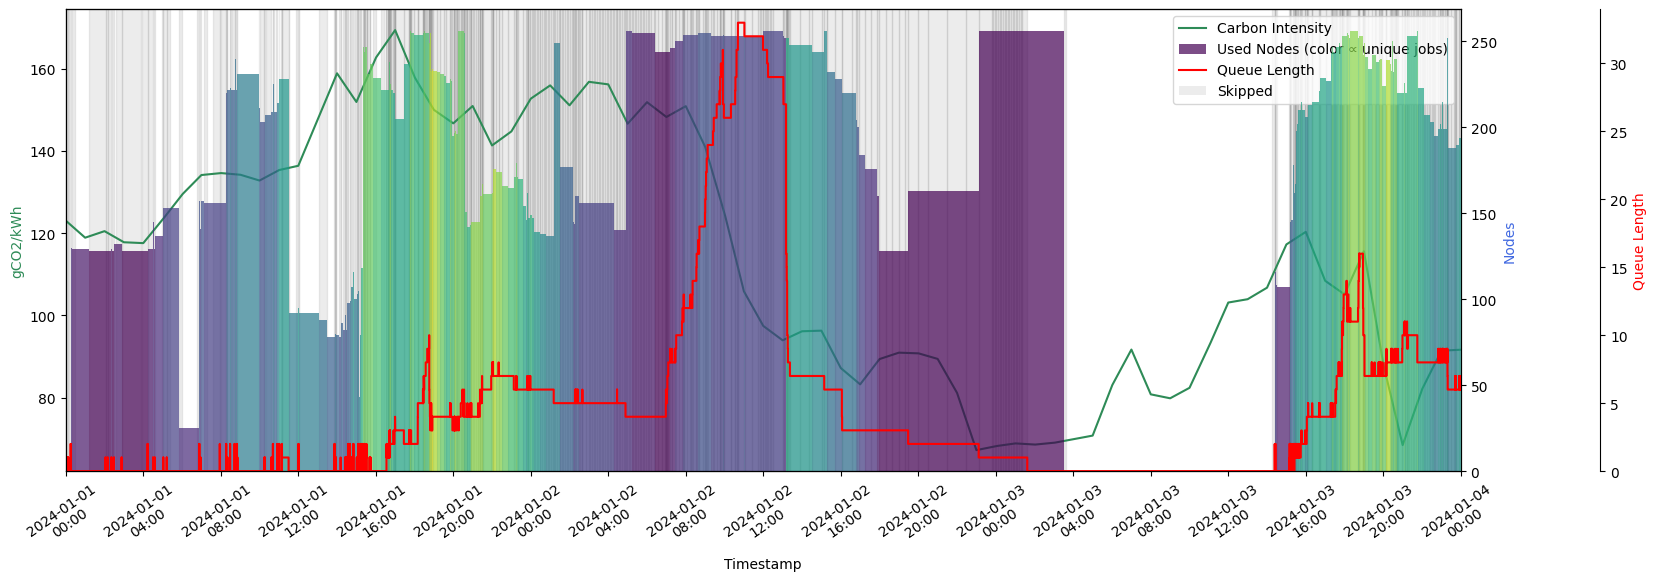

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val = Validation()
val.load_dir(train_and_eval_folder)


val.render_timeseries_plot(results[1]["trace"]['model']['action_traces'], start_time = 3600*24*0, end_time = 3600*24*3, name = "seed_3_eta_0.5")

In [6]:
train_and_eval_folder = "results/train_and_eval/session_20251019-154859Z-09cdbf/user_ci_disabled/eta_0.001"

seeds = 5
results = {}
seeds = [1]
for seed in seeds:
    results[seed] = {}
    results[seed]["processed_results"] = {}
    results[seed]["trace"] = {}
for seed in seeds:
    val = Validation()
    val.load_dir(train_and_eval_folder)
    model_loc = train_and_eval_folder + "/seed_" + str(seed) + "/" "best_model"
    model = MaskablePPO.load(path=model_loc)
    processed_results, trace = val.validate_model(1,model,"test")
    results[seed]["processed_results"] = processed_results
    results[seed]["trace"] =trace 


FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/train_and_eval/session_20251019-154859Z-09cdbf/user_ci_disabled/eta_0.001/config.json'. Please ensure it exists.

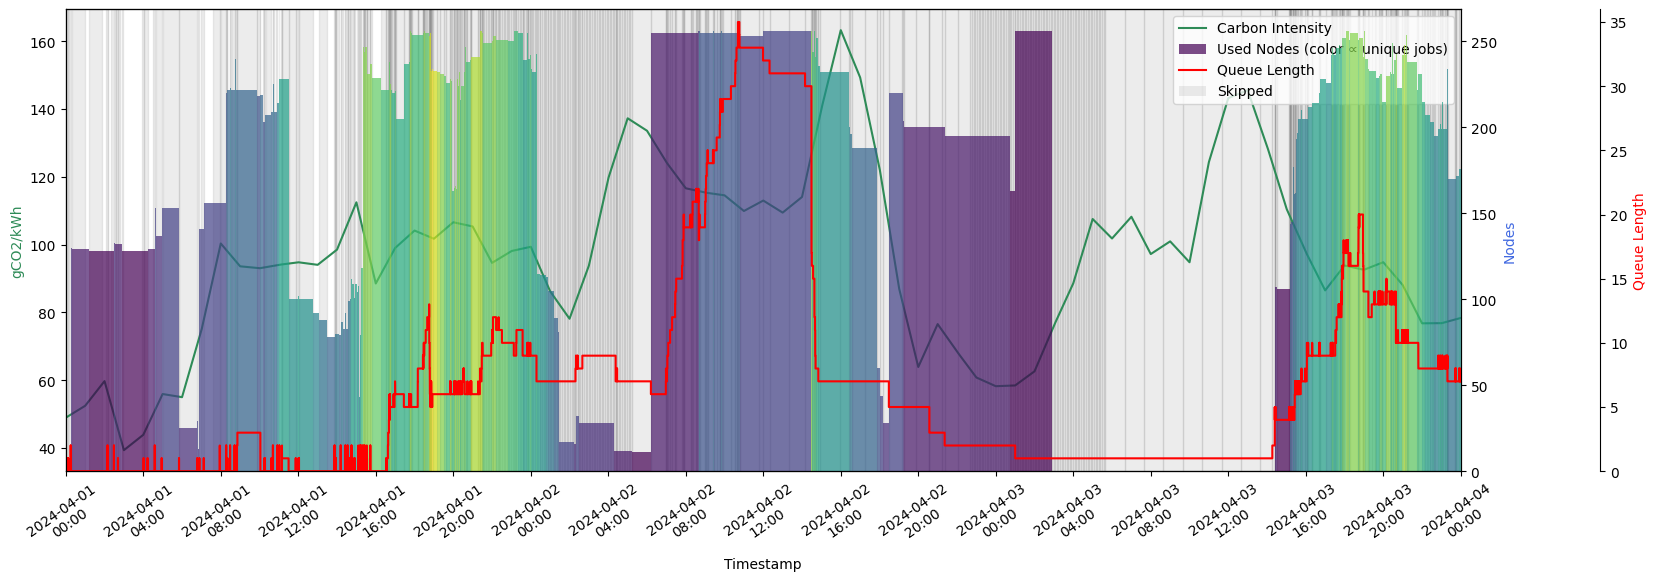

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.render_timeseries_plot(results[1]["trace"]['model']['action_traces'], start_time = 3600*24*0, end_time = 3600*24*3, name = "seed_3_eta_0.5")

In [ ]:
raw_stats_baselines.keys()

dict_keys(['FCFS Baseline', '10-percentile Baseline', '25-percentile Baseline', '50-percentile Baseline', '60-percentile Baseline', '70-percentile Baseline', '80-percentile Baseline', '90-percentile Baseline', '95-percentile Baseline', '97-percentile Baseline'])

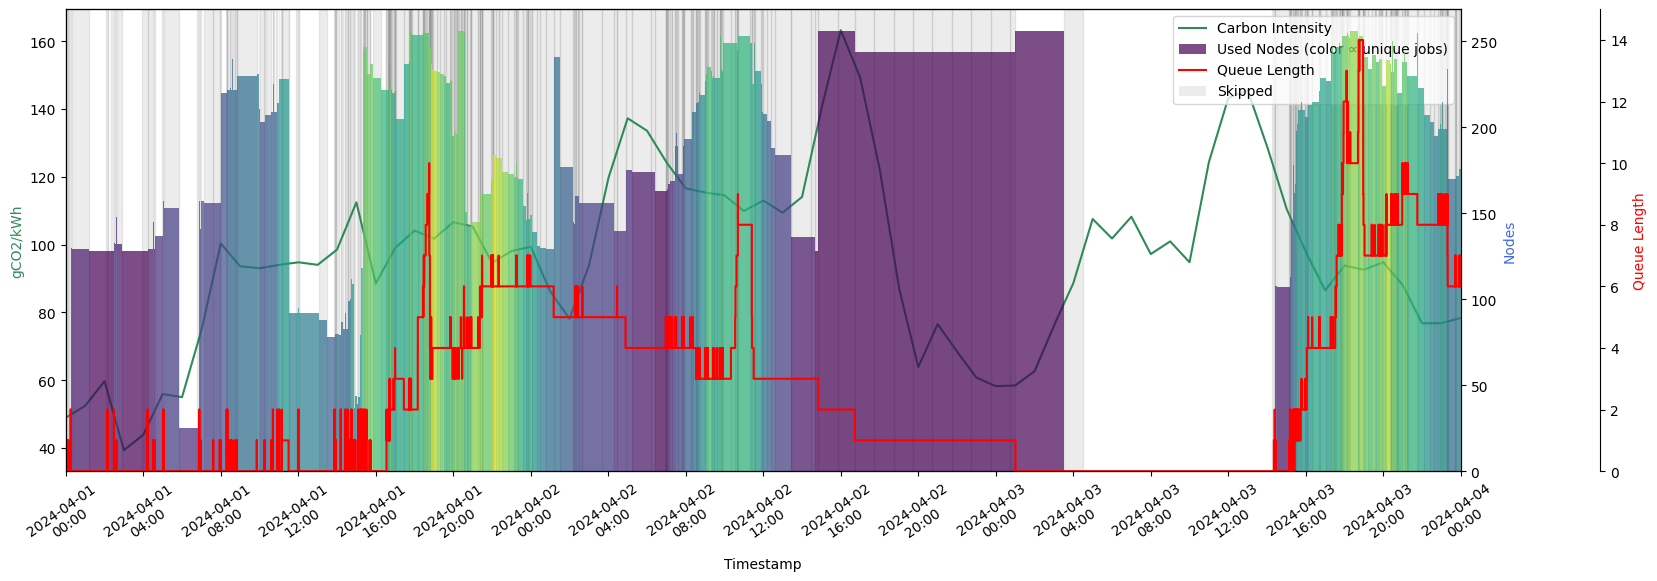

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.render_timeseries_plot(raw_stats_baselines['FCFS Baseline']["action_traces"], start_time = 3600*24*0, end_time = 3600*24*3, name = "seed_3_eta_0.5")

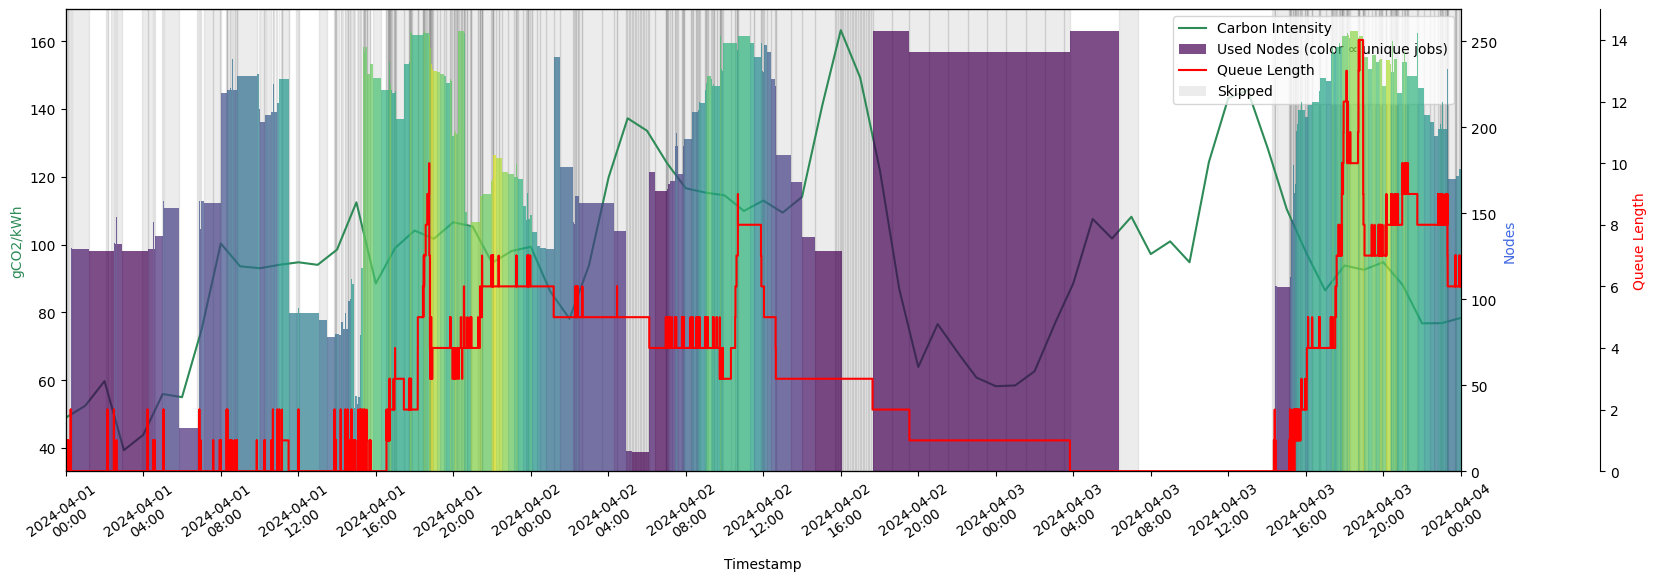

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.render_timeseries_plot(raw_stats_baselines['97-percentile Baseline']["action_traces"], start_time = 3600*24*0, end_time = 3600*24*3, name = "seed_3_eta_0.5")

In [ ]:
results = best_fit_on_test_workload()

KeyError: 3

In [ ]:
## Wait time distribution for fcfs

